# 02 · Starting from a TIFF stack

**Audience:** users whose detector writes one TIFF per frame, with darks
/ whites / projections all numbered in one indexed series — the layout
that the `prepare_data_*.py` scripts in `okasinski1id_jun25/tomo/`
consume.

**Goal:** discover the index ranges, read the right frames, assemble the
raw binary that MIDAS expects, and reconstruct.

A synthetic TIFF folder is generated below so this runs anywhere; point
`TIFF_DIR` at your own folder to use the same code on real data.


In [1]:
# --- Setup ---------------------------------------------------------
%matplotlib inline
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Make the MIDAS TOMO Python API importable
MIDAS_TOMO = os.path.expanduser('~/opt/MIDAS/TOMO')
if MIDAS_TOMO not in sys.path:
    sys.path.insert(0, MIDAS_TOMO)
NB_DIR = os.path.join(MIDAS_TOMO, 'notebooks')
if NB_DIR not in sys.path:
    sys.path.insert(0, NB_DIR)

import _phantom as phantom

# Working directory for this notebook's outputs
WORK = os.path.expanduser('~/tomo_notebooks/02_tiff')
os.makedirs(WORK, exist_ok=True)
print('Working dir:', WORK)


Working dir: /Users/hsharma/tomo_notebooks/02_tiff


## 1 · Generate (or point at) a synthetic TIFF stack

The phantom emits four "runs" in one indexed series:

| Range            | Contents              |
|------------------|-----------------------|
| 000001 – 000010  | dark frames           |
| 000100 – 000109  | white frames (before) |
| 000200 – 000379  | projection frames     |
| 000380 – 000389  | white frames (after)  |

Real APS scans use the same pattern, just with bigger indices.


In [2]:
TIFF_DIR = os.path.join(WORK, 'tiffs')

vol = phantom.make_phantom(48, 48, 48)
angles = np.arange(0, 180, 1.0, dtype=np.float32)
acq = phantom.make_acquisition(vol, angles, add_rings=True)
info = phantom.write_synthetic_tiff_stack(TIFF_DIR, acq, stem='phantom')
for k, v in info.items():
    print(f'  {k:14s} : {v}')


  pattern        : /Users/hsharma/tomo_notebooks/02_tiff/tiffs/phantom_<index:06d>.tif
  dark           : (1, 10)
  white_before   : (100, 109)
  data           : (200, 379)
  white_after    : (380, 389)


## 2 · Discover the file naming pattern

On real data you typically don't have the index ranges spelled out —
you have a folder full of TIFFs and a screenful of beamline notes.
Here is the discovery snippet that mirrors what the `prepare_data`
scripts do by hand.


In [3]:
import re
import glob

tifs = sorted(glob.glob(os.path.join(TIFF_DIR, '*.tif')))
print(f'Found {len(tifs)} TIFFs')
print('First 3:', [os.path.basename(p) for p in tifs[:3]])
print('Last 3:',  [os.path.basename(p) for p in tifs[-3:]])

# Pull the numeric index out of each filename
rx = re.compile(r'(\d+)\.tif$')
indices = np.array([int(rx.search(p).group(1)) for p in tifs])
print(f'Index range: {indices.min()} ... {indices.max()}')


Found 210 TIFFs
First 3: ['phantom_000001.tif', 'phantom_000002.tif', 'phantom_000003.tif']
Last 3: ['phantom_000387.tif', 'phantom_000388.tif', 'phantom_000389.tif']
Index range: 1 ... 389


## 3 · Decide which indices are darks, whites, projections

On real data you would learn the index ranges from the beamline log.
For this notebook the synthetic dict says it directly — re-use those
numbers in the next cell.


In [4]:
DARK_START,  N_DARK  = info['dark'][0],         info['dark'][1] - info['dark'][0] + 1
WHITE_START, N_WHITE = info['white_before'][0], info['white_before'][1] - info['white_before'][0] + 1
DATA_START,  N_DATA  = info['data'][0],         info['data'][1] - info['data'][0] + 1
WHITE2_START         = info['white_after'][0]

print(f'N darks: {N_DARK} starting at {DARK_START}')
print(f'N whites (each side): {N_WHITE}')
print(f'N projections: {N_DATA}')


N darks: 10 starting at 1
N whites (each side): 10
N projections: 180


## 4 · Read and average dark / white frames

Averaging is cheap noise reduction. If you have many darks/whites the
bias / flat-field estimate is much more stable than a single frame.


In [5]:
from PIL import Image
STEM = 'phantom'

def read_tif(idx):
    return np.array(Image.open(
        os.path.join(TIFF_DIR, f'{STEM}_{idx:06d}.tif')
    ), dtype=np.float32)

def avg_range(start, n):
    return np.mean([read_tif(start + i) for i in range(n)], axis=0
                   ).astype(np.float32)

dark = avg_range(DARK_START, N_DARK)
white_before = avg_range(WHITE_START, N_WHITE)
white_after = avg_range(WHITE2_START, N_WHITE)
print('shapes:', dark.shape, white_before.shape, white_after.shape)


shapes: (48, 48) (48, 48) (48, 48)


## 5 · Visualize a representative dark, white, and projection


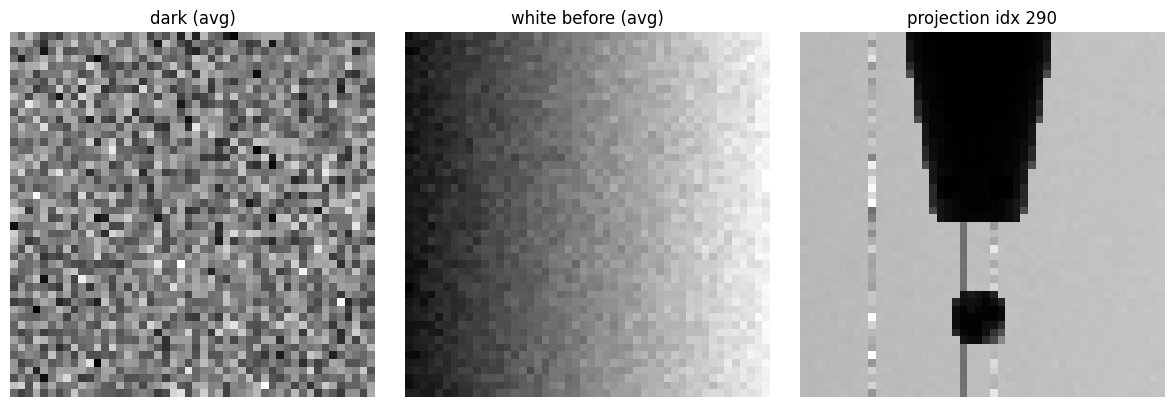

In [6]:
proj_mid = read_tif(DATA_START + N_DATA // 2)
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, im, t in zip(ax, [dark, white_before, proj_mid],
                    ['dark (avg)', 'white before (avg)',
                     f'projection idx {DATA_START + N_DATA//2}']):
    a.imshow(im, cmap='gray'); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()


## 6 · Stream the projections through to a single dark + 2 whites + uint16 raw

The C engine reads raw projections from one binary file: dark (float32)
+ 2 whites (float32) + n projections (uint16). Streaming avoids
loading the full stack into RAM.


In [7]:
raw_path = os.path.join(WORK, f'data_{STEM}.raw')

with open(raw_path, 'wb') as f:
    dark.astype(np.float32).tofile(f)
    white_before.astype(np.float32).tofile(f)
    white_after.astype(np.float32).tofile(f)
    for i in range(N_DATA):
        read_tif(DATA_START + i).astype(np.uint16).tofile(f)
        if (i + 1) % 50 == 0:
            print(f'  wrote projection {i + 1}/{N_DATA}')

print(f'Raw size: {os.path.getsize(raw_path) / 1e6:.1f} MB')


  wrote projection 50/180


  wrote projection 100/180


  wrote projection 150/180
Raw size: 0.9 MB


## 7 · Reconstruct via the Python API

`run_tomo()` takes the in-memory arrays and runs the C engine for us.
For larger datasets where streaming-to-disk matters, you can also call
`MIDAS_TOMO` directly with a parameter file pointing at `raw_path` —
see notebook 04 for that pattern.


In [8]:
from midas_tomo_python import run_tomo

proj_stack = np.stack([read_tif(DATA_START + i).astype(np.uint16)
                       for i in range(N_DATA)])

recon = run_tomo(
    proj_stack, dark,
    np.stack([white_before, white_after]),
    WORK, angles, shifts=0.0, numCPUs=4, doCleanup=1,
)
print('recon:', recon.shape)


Time elapsed in preprocessing: 0.001s.


Version: MIDAS v11.0 (8a155821)
Total number of thetas: 180
We are doing all slices. Total number of slices: 48

          MIDAS TOMO - Configuration Summary
  Data Input:
    Data File       : /Users/hsharma/tomo_notebooks/02_tiff/input.bin
    Input Type      : Raw Projections
    Recon Output    : /Users/hsharma/tomo_notebooks/02_tiff/output
  Detector:
    Dimensions      : 48 x 48 (X x Y)
  Angles:
    Theta Count     : 180
    Range           : 0.00 to 179.00
  Reconstruction:
    Filter          : 2
    Shift Range     : 0.00 to 0.00 (step 1.00, n=1)
    Slices          : 48
    Auto Centering  : Yes
    Log Projection  : Yes
    Extra Padding   : 0
    Save Separate   : No
  Corrections:
    Ring Removal    : No
    Stripe Removal  : No

Sinograms are not a power of 2.  They will be increased to 64
Reading wisdom file fftwf_wisdom_2d_128.txt.
Memory needed per process: 1549242, Total available RAM: 68719476736, MaxNProcs: 44356.
We can run up to 44354 processes.
We will use 6 

## 8 · Visualize the reconstruction


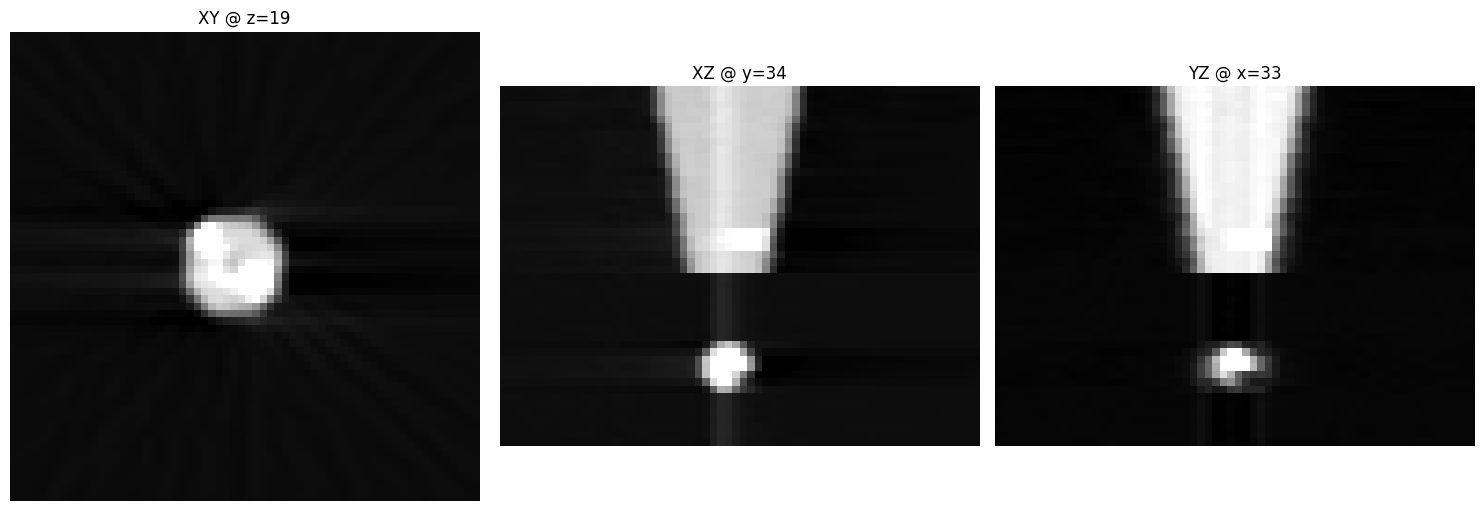

In [9]:
cube = recon[0]
zb, yb, xb = np.unravel_index(np.argmax(cube), cube.shape)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, im, t in zip(ax,
                    [cube[zb], cube[:, yb, :], cube[:, :, xb]],
                    [f'XY @ z={zb}', f'XZ @ y={yb}', f'YZ @ x={xb}']):
    vmin, vmax = np.percentile(im, 1), np.percentile(im, 99)
    a.imshow(im, cmap='gray', vmin=vmin, vmax=vmax, aspect='equal')
    a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()


## 9 · Real-world variations

The reconstruction probably shows ring artefacts (we injected them).
Continue with **[03_cleanup_tuning.ipynb](03_cleanup_tuning.ipynb)** to
knock them out.

Other common TIFF-stack situations:

- **No "white after" frames.** Skip them — pass the same `white_before`
  array twice into the 2-whites argument.
- **`bright/dark` are scattered through the data series.** Identify them
  by index via the beamline log; the read-loop above is unchanged.
- **Multiple shutter modes.** Some scans interleave dark and projection
  frames. Filter them out by index parity or by the beamline metadata
  file before reading.
- **HDF5 instead of TIFFs.** Use
  **[01_quickstart_hdf5.ipynb](01_quickstart_hdf5.ipynb)** — the
  MIDAS API is the same, only the data-loading code changes.
